#Q3. Feature Engineering and Regression Pipeline

In [60]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set(style="whitegrid")

##1. Date Feature Engineering

In [61]:
df = pd.read_csv("/content/sample_data/q3_retail_promotions.csv")

# convert to datetime and extract
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# month-end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


##2. Temporal Train-Test Split

In [62]:
# sort by date
df = df.sort_values(by='transaction_date')

# split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


#### Why a random split is inappropriate for time-ordered data?

A random split is inappropriate for time-ordered data because it ignores the natural sequence of events. When data is split randomly, it can lead to data leakage, where future information is used to predict past values. For time series data, order must be preserved by training on earlier time periods and testing on later ones. So, we use temporal split where model is trained on past data and tested on future data.

##3. Preprocessing Pipeline

In [63]:
# define target and features
target = 'items_sold'

X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

In [64]:
# categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

In [65]:
# column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

##4. Model Training and Evaluation

In [67]:
# linear regression pipeline
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# random forest pipeline
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [68]:
# train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [69]:
# predict
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [71]:
# metrics
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{model_name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588388

Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


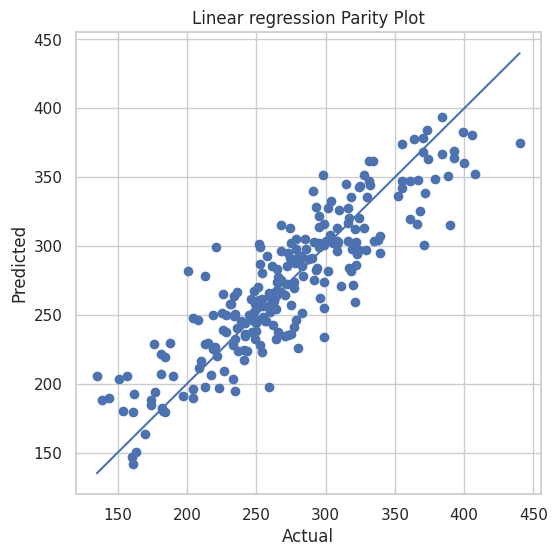

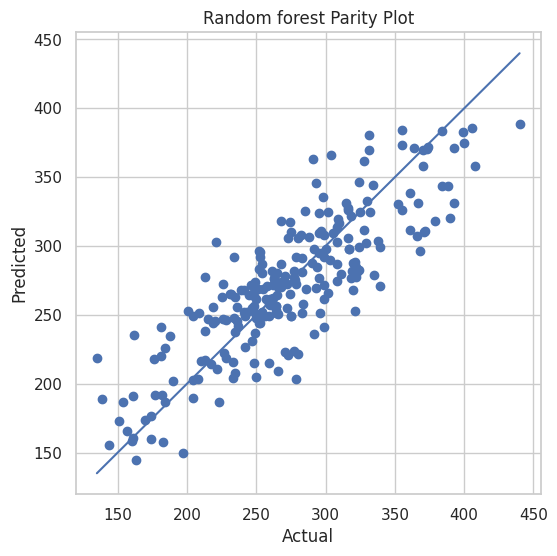

In [74]:
# parity plot
def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred)

    # diagonal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(y_test, y_pred_lr, "Linear regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random forest Parity Plot")

In [75]:
# feature importance
ohe = rf_pipeline.named_steps['preprocessing'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + numerical_cols

# get important features
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
7,store_size_small,0.183954
10,is_festival,0.174477
5,location_type_urban,0.140498
14,day_of_week,0.090612
9,is_weekend,0.063547
8,store_id,0.062056
6,store_size_medium,0.058178
11,competition_density,0.053486
13,month,0.040473
4,location_type_semi-urban,0.038886


#### Feature Importance Interpretation

The top 5 most influential features identified by the Random Forest model are:

1. store_size_small (0.1839)
2. is_festival (0.1745)
3. location_type_urban (0.1405)
4. day_of_week (0.0906)
5. is_weekend (0.0635)

These features have the highest impact on predicting the number of items sold.